# Functional and Noisy Signal Population

This notebook covers generating deterministic mathematical signals (trigonometric, exponential, polynomial) and populating them with stochastic/random noise (Gaussian, Uniform, Salt & Pepper) to simulate real-world sensor data, time-series, and experimental measurements using **NumPy** and **Matplotlib**.

---

In [ ]:
# All required installations
# !pip install numpy matplotlib

In [1]:
# All Imports here
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Apply clean visual stylings
plt.style.use('seaborn-whitegrid' if 'seaborn-whitegrid' in plt.style.available else 'default')
# Runtime Configuration for visualizations
plt.rcParams['figure.dpi'] = 100
# reproducible stichastic generation through seed set
np.random.seed(seed=42)  # Set the seed for reproducibility

#### 1. Trigonometric Harmonic Signal + Additive Gaussian Noise

### Overview & Purpose
- Models physical periodic signals (e.g., audio waves, AC current, cyclical seasonal trends) obscured by Gaussian (Normal) white noise. 
- It demonstrates how to combine pure deterministic sine/cosine waves with zero-mean normal error distributions.

### Mathematical Formula
The pure functional signal $y_{\text{pure}}(t)$ and noisy population $y_{\text{noisy}}(t)$ are defined as:

$$y_{\text{pure}}(t) = A \cdot \sin(2\pi f t + \phi)$$

$$y_{\text{noisy}}(t) = y_{\text{pure}}(t) + \epsilon, \quad \epsilon \sim \mathcal{N}(\mu, \sigma^2)$$

**Pronunciation & Symbol Guide:**
* $A$: Signal amplitude (*A*).
* $f$: Frequency in Hertz / cycles per unit time (*f*).
* $\phi$: Phase shift angle (*phi*).
* $\epsilon$: Random additive noise perturbation (*epsilon*).
* $\mathcal{N}(\mu, \sigma^2)$: Normal distribution with mean $\mu$ and standard deviation $\sigma$.

### Parameters
* `loc`: `float` — Mean $\mu$ of the Gaussian noise (centered at 0 for unbiased noise).
* `scale`: `float` — Standard deviation $\sigma$ controlling noise intensity.
* `size`: `int` or `tuple` — Output shape matching the signal array length.

Harmonic signal generated successfully with gaussian noise.
Time Domain Array Length: 200
Pure signal range :[-3.00, 3.00] 
Noisy signal range :[-3.87, 4.24] 
Calculated Noise variance :0.3490


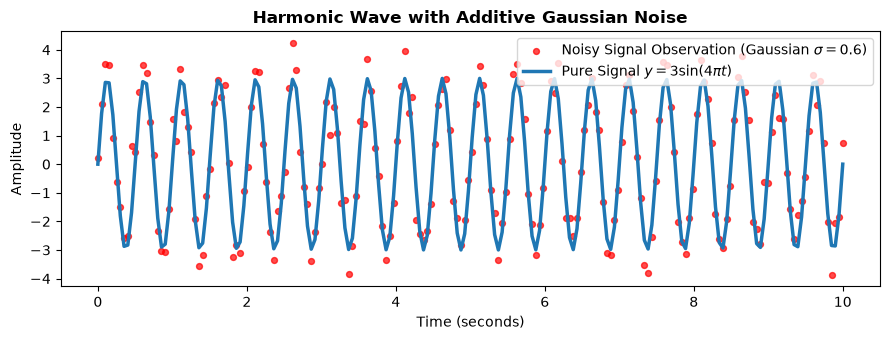

In [ ]:
t = np.linspace(
    start = 0,  # Start of the time interval
    stop = 10,  # End of the time interval
    num = 200  # Number of evenly spaced points
    )  
f = 2.0 # Frequency of the signal
A = 3.0  # Amplitude of the signal
# Generate the clean sinusoidal signal
y_pure = A * np.sin(2 * np.pi * f * t)
# Add Gaussian noise to the clean signal (mean = 0, standard deviation = 0.6)
gaussian_noise = np.random.normal(
    loc=0.0, # Mean of the Gaussian noise
    scale=0.6,  # Standard deviation of the Gaussian noise
    size=len(t)
    )
# Generate the noisy signal by adding the Gaussian noise to the clean signal
y_noisy = y_pure + gaussian_noise

print("Harmonic signal generated successfully with gaussian noise.")
print("Time Domain Array Length:", len(t))
print(f"Pure signal range :[{y_pure.min():.2f}, {y_pure.max():.2f}] ")
print(f"Noisy signal range :[{y_noisy.min():.2f}, {y_noisy.max():.2f}] ")
print(f"Calculated Noise variance :{np.var(gaussian_noise):.4f}")

plt.figure(figsize=(9, 3.5))

# noisy observation (scatter plot)
plt.scatter(
    x=t,                # X-coordinate (time values)
    y=y_noisy,          # Y-coordinate (noisy signal values)
    color='red',        # Color of the scatter points
    s=18 ,              # Size of the scatter points (marker size)
    alpha=0.7,          # Transparency of the scatter points
    zorder=2 ,           # Drawing order of the scatter points
    label='Noisy Signal Observation (Gaussian $\\sigma=0.6$)', # legend label for the scatter plot
    )

# Pure Underlying Signal (Line Plot)
plt.plot(
    t,                                                     # X-axis sequence (time values)
    y_pure,                                                # Y-axis sequence (clean signal values)
    color='#1f77b4',                                       # Standard dark blue line color
    linewidth=2.5,                                         # Thickness of the plot line
    zorder=3,                                              # Drawn on top of scatter points
    label='Pure Signal $y = 3\\sin(4\\pi t)$'               # Legend label entry
)

plt.title(
    label='Harmonic Wave with Additive Gaussian Noise',    # Figure title text
    fontsize=12,                                           # Title font size in points
    fontweight='bold'                                      
)

plt.xlabel(xlabel='Time (seconds)')                       # X-axis label text
plt.ylabel(ylabel='Amplitude')                            # Y-axis label text
plt.legend(loc='upper right')                             # Corner anchor position for legend box
plt.tight_layout()                                        # Automatically adjusts subplots to fit figure area
plt.show()


## 2. Exponential Decay + Uniform Measurement Error

### Overview & Purpose
Simulates physical decay dynamics (e.g., radioactive decay, capacitor discharge, thermal cooling) subjected to bounded quantization or sensor tolerance error modeled by a Uniform distribution.

- Quantization :  converting continuous measurements to discrete levels. 
-               : reducing the precission of a digital signal from a higher to lower precission

### Mathematical Formula
Given initial value $N_0$ and decay constant $\lambda$:

$$y_{\text{decay}}(t) = N_0 \cdot e^{-\lambda t}$$

$$y_{\text{measured}}(t) = y_{\text{decay}}(t) + u, \quad u \sim \mathcal{U}(-w, +w)$$

**Pronunciation & Symbol Guide:**
* $N_0$: Initial concentration/quantity at $t=0$ (*N sub zero*).
* $\lambda$: Decay rate parameter (*lambda*).
* $u$: Bounded uniform noise variable (*u*).
* $\mathcal{U}(-w, +w)$: Continuous uniform distribution bounded between $-w$ and $+w$.

### Parameters
* `low`: `float` — Lower bound of the noise interval ($-w$).
* `high`: `float` — Upper bound of the noise interval ($+w$).
* `size`: `int` or `tuple` — Output shape matching the signal array length.

=== 2. EXPONENTIAL DECAY + UNIFORM ERROR ===
Initial Pure Value at t=0: 10.00
Final Pure Value at t=5: 0.1832
Uniform Error Bounds: [-0.4799, 0.4900]



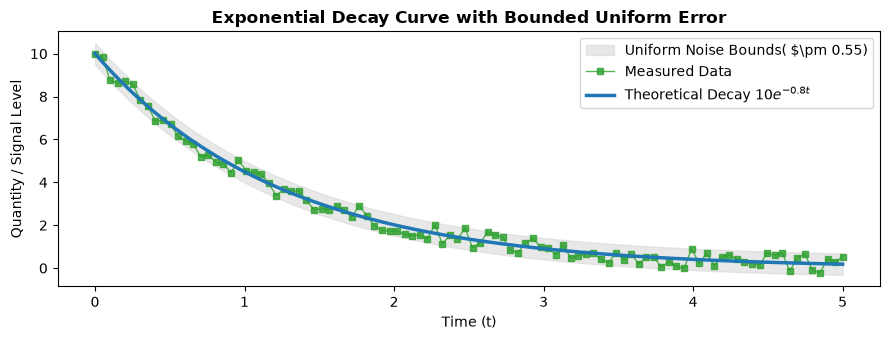

In [ ]:
# Generate decay signal
t_decay = np.linspace(
    start=0.0,  # Start of time interval
    stop=5.0,   # End of time interval (5 seconds duration)
    num=100     # Total number of generated evaluation steps
)
N0 = 10.0  # Initial quantity at time t=0
decay_rate = 0.8 # decay constant lambda

# Generate the decay signal
y_decay_pure  = N0 * np.exp(-decay_rate * t_decay)

# generate bounded uniform measurement error in interval [-0.5, 0.5]
uniform_noise = np.random.uniform(
    low=-0.5,   # Lower bound of the uniform noise
    high=0.5,   # Upper bound of the uniform noise
    size=len(t_decay)  # Number of noise samples equal to the number of time points
)

# Generate the noisy decay signal by adding the uniform noise to the pure decay signal
y_decay_measured = y_decay_pure + uniform_noise

print("=== 2. EXPONENTIAL DECAY + UNIFORM ERROR ===")
print(f"Initial Pure Value at t=0: {y_decay_pure[0]:.2f}")
print(f"Final Pure Value at t=5: {y_decay_pure[-1]:.4f}")
print(f"Uniform Error Bounds: [{uniform_noise.min():.4f}, {uniform_noise.max():.4f}]\n")

# graphical representation of the decay signal
plt.figure(figsize=(9, 3.5))

# Bounded noise band visualization (shaded envelope)
plt.fill_between(
    x=t_decay,
    y1=y_decay_pure - 0.5,
    y2=y_decay_pure + 0.5,
    color='lightgray',  # Color of the shaded envelope
    alpha=0.5,          # Transparency of the shaded envelope
    label='Uniform Noise Bounds( $\\pm 0.55)'
)

# Plotting measured samples
plt.plot(
    t_decay,                                                # X-coordinates (time values)
    y_decay_measured,                                       # Y-coordinates (measured noisy signal values)
    's-',                                                   # Marker & line style format (square markers with solid line)
    color='#2ca02c',                                        # Forest green line color
    linewidth=1,                                            # Thickness of connecting line
    markersize=4,                                           # Vertex square marker side dimension
    alpha=0.8,                                              # Line opacity
    label='Measured Data'                                   # Legend label entry
)


plt.plot(
    t_decay,                                                # X-coordinates (time values)
    y_decay_pure,                                           # Y-coordinates (pure theoretical decay curve)
    color='#1f77b4',                                        # Dark blue color
    linewidth=2.5,                                          # Line thickness for ground truth curve
    label='Theoretical Decay $10 e^{-0.8t}$'                # Legend entry with LaTeX equation
)
plt.title(
    label='Exponential Decay Curve with Bounded Uniform Error',  # Plot title
    fontsize=12,                                                # Title text font size
    fontweight='bold'                                           # Bold title font weight
)
plt.xlabel(xlabel='Time (t)')                               # X-axis domain title
plt.ylabel(ylabel='Quantity / Signal Level')                # Y-axis range title
plt.legend(loc='upper right')                             # Position legend in upper right corner
plt.tight_layout()                                        # Optimize plot margin spacing
plt.show()

#### 3. Polynomial Function + Sparse Outliers (Salt & Pepper / Impulse Noise)
### Overview & Purpose
- Models smooth polynomial trends contaminated by severe intermittent sensor corruptions, dropped packets, or hardware glitches (Impulse or Salt & Pepper noise). 
- Demonstrates how sparse extreme values alter dataset statistics.


### Mathematical Formula
Given a cubic polynomial curve $p(x)$:

$$p(x) = a_3 x^3 + a_2 x^2 + a_1 x + a_0$$

Outliers are injected into a random subset of indices $I_{\text{outlier}} \subset \{0, 1, \dots, N-1\}$:

$$y_{\text{corrupted}}[i] = \begin{cases} p(x_i) + \eta_i, & \text{if } i \in I_{\text{outlier}} \quad (\eta_i \text{ is a large spike}) \\ p(x_i), & \text{otherwise} \end{cases}$$

**Pronunciation & Symbol Guide:**
* $p(x)$: Deterministic polynomial function (*p of x*).
* $I_{\text{outlier}}$: Index set chosen for outlier injection (*outlier index set*).
* $\eta_i$: High-amplitude spike value (*eta sub i*).

### Parameters
* `outlier_fraction`: `float` — Percentage of total data points converted to outliers (e.g., `0.08` = 8%).
* `spike_magnitude`: `float` — Scale multiplier determining the height/severity of noise spikes.


=== 3. POLYNOMIAL + IMPULSE OUTLIERS ===
Total Data Points: 120
Injected Outlier Count: 9
Outlier Indices: [ 93 112   5  53 118  75  35  56  27]
Clean Data Mean: 0.6443 | Corrupted Data Mean: 0.9099



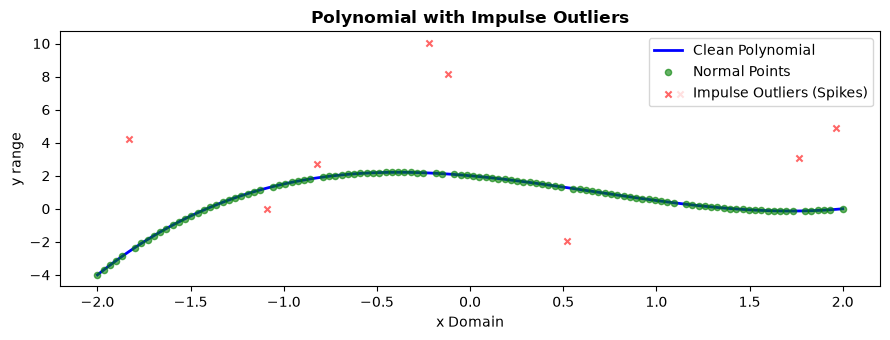

In [11]:
x_poly = np.linspace(
    start=-2.0,  # Lower domain boundary
    stop=2.0,    # Upper domain boundary
    num=120      # Total grid point resolution count
)

# Cubic Polynomial: p(x) = 0.5*x^3 - x^2 - x + 2
y_poly_clean = 0.5 * (x_poly**3) - (x_poly**2) - x_poly + 2
y_poly_corrupted = y_poly_clean.copy()

# select 8% of indices randomly to inject impulse spikes
num_outliers = int(0.08 * len(x_poly))  # 8% of the total number of points
outlier_indices = np.random.choice(
    a=len(x_poly),  # sampling population size index range
    size=num_outliers,  # Number of outlier indices to select
    replace=False       # Ensure unique selection of indices
)

# Inject random positive and negative spikes
spikes_magnitude = np.random.uniform(
    low=-4.0,   # Minimum spike magnitude
    high=8.0,   # Maximum spike magnitude
    size=num_outliers  # Number of spikes to generate
)
y_poly_corrupted[outlier_indices] += spikes_magnitude

print("=== 3. POLYNOMIAL + IMPULSE OUTLIERS ===")
print(f"Total Data Points: {len(x_poly)}")
print(f"Injected Outlier Count: {num_outliers}")
print(f"Outlier Indices: {outlier_indices}")
print(f"Clean Data Mean: {y_poly_clean.mean():.4f} | Corrupted Data Mean: {y_poly_corrupted.mean():.4f}\n")

plt.figure(figsize=(9, 3.5))
plt.plot(
    x_poly,                     # Domain coordinates
    y_poly_clean,               # Clean polynomial values
    label="Clean Polynomial",   # Legend label for the clean polynomial curve
    color="blue", 
    linewidth=2,
    zorder=2
    )

# Uncurrupted points (regular observations)
normal_mask = np.ones_like(x_poly, dtype=bool)
normal_mask[outlier_indices] = False

plt.scatter(
    x = x_poly[normal_mask],          # Domain coordinates for normal points
    y = y_poly_corrupted[normal_mask],# Corrupted polynomial values for normal points
    label="Normal Points",  # Legend label for normal observations
    color="green", 
    s=20,                         # Marker size
    zorder=3,
    alpha = 0.6
)

# Outlier points (impulse spikes highlighted in red)
plt.scatter(
    x = x_poly[outlier_indices],          # Domain coordinates for outlier points
    y = y_poly_corrupted[outlier_indices],# Corrupted polynomial values for outlier points
    label="Impulse Outliers (Spikes)",  # Legend label for outlier observations
    color="red", 
    s=20,                         # Marker size
    zorder=2,
    alpha = 0.6,
    marker="x"
)

plt.title(
    label="Polynomial with Impulse Outliers",
    fontsize=12,
    fontweight="bold"
)
plt.xlabel(xlabel="x Domain")
plt.ylabel(ylabel="y range")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

### 4. Multi-Component Composite Signal + Heteroscedastic Noise
### Overview & Purpose
Generates complex real-world signals consisting of a linear trend, multiple oscillating frequencies, and **heteroscedastic noise** (where noise variance increases dynamically over time, common in financial volatility and expanding drift sensors).


### Mathematical Formula
The composite functional signal $S(t)$ combines linear trend and two sine components:

$$S(t) = (m \cdot t + c) + A_1 \sin(2\pi f_1 t) + A_2 \sin(2\pi f_2 t)$$

Heteroscedastic noise standard deviation $\sigma(t)$ expands proportionally with $t$:

$$\sigma(t) = \sigma_0 + \gamma \cdot t, \quad y_{\text{composite}}(t) = S(t) + \mathcal{N}(0, \sigma(t)^2)$$

**Pronunciation & Symbol Guide:**
* $m$: Linear trend slope (*m*).
* $f_1, f_2$: Primary and secondary harmonic frequencies (*f sub 1, f sub 2*).
* $\sigma(t)$: Time-varying standard deviation (*sigma of t*).
* $\gamma$: Noise expansion rate coefficient (*gamma*).
* $A_1$ and $A_2$ are the Amplitudes of two distinct sinusoidal waves (cycles or periodic components).
* $c$: Baseline offset / $y$-intercept at $t=0$

### Parameters
* `sigma_0`: Base standard deviation at $t=0$.
* `gamma`: Expansion multiplier rate of noise amplitude over time.

=== 4. COMPOSITE SIGNAL + HETEROSCEDASTIC NOISE ===
Initial Noise Std Dev (t=0): 0.10
Final Noise Std Dev (t=10): 1.10
Overall Composite Signal Length: 300



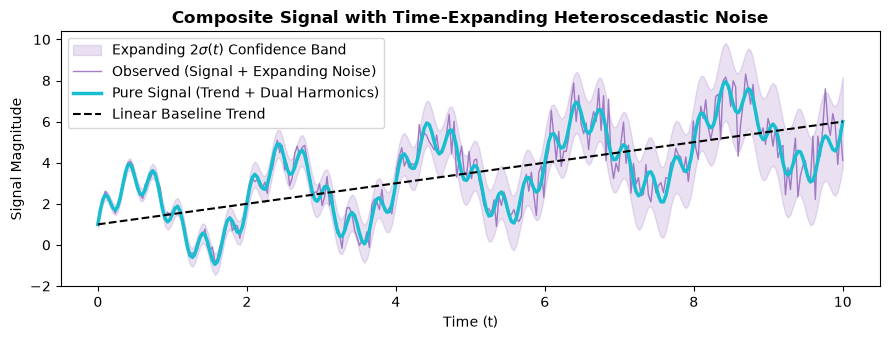

In [ ]:
t_comp = np.linspace(
    start=0.0,  # Start time in seconds
    stop=10.0,  # Stop time in seconds (10 second window)
    num=300     # Evaluation step count
)

trend = 0.5 * t_comp + 1.0 # Component 1: Linear upward trend (m=0.5, c=1.0)

harmonics = 2.0 * np.sin(2 * np.pi * 0.5 * t_comp) + 0.8 * np.sin(2 * np.pi * 3.0 * t_comp) # Component 2 & 3: Dual-frequency harmonics (0.5 Hz low freq + 3.0 Hz high freq)

S_pure = trend + harmonics # Combined signal: Trend + Harmonics

sigma_t = 0.1 + 0.1 * t_comp # Time-dependent standard deviation: sigma grows from 0.1 at t=0 to 1.1 at t=10

hetero_noise = np.random.normal(
    loc=0.0,           # Zero mean base noise distribution
    scale=1.0,         # Standard unit normal standard deviation
    size=len(t_comp)   # Sample size matching domain array length
) * sigma_t
y_composite = S_pure + hetero_noise # Final noisy signal: Pure signal + Heteroscedastic noise

print("=== 4. COMPOSITE SIGNAL + HETEROSCEDASTIC NOISE ===")
print(f"Initial Noise Std Dev (t=0): {sigma_t[0]:.2f}")
print(f"Final Noise Std Dev (t=10): {sigma_t[-1]:.2f}")
print(f"Overall Composite Signal Length: {len(y_composite)}\n")

# Graphical visualization
plt.figure(figsize=(9, 3.5))

# Time-expanding error region visual
plt.fill_between(
    x=t_comp,                                                      # Time axis coordinates
    y1=S_pure - 2 * sigma_t,                                      # Lower 2-sigma lower envelope threshold
    y2=S_pure + 2 * sigma_t,                                      # Upper 2-sigma upper envelope threshold
    color='#9467bd',                                               # Soft purple fill color
    alpha=0.2,                                                     # Envelope translucent shading factor
    label='Expanding $2\\sigma(t)$ Confidence Band'                 # Legend label
)

# Observed composite series plot
plt.plot(
    t_comp,                                                        # Time grid
    y_composite,                                                   # Signal + heteroscedastic noise observations
    color='#9467bd',                                               # Muted purple line color
    linewidth=1.0,                                                 # Thin line for noisy signal details
    alpha=0.85,                                                    # Translucency level
    label='Observed (Signal + Expanding Noise)'                    # Legend text
)
plt.plot(
    t_comp,                                                        # Time grid
    S_pure,                                                        # Pure combined signal values
    color='#17becf',                                               # Cyan line color
    linewidth=2.5,                                                 # Line stroke thickness
    label='Pure Signal (Trend + Dual Harmonics)'                  # Legend text
)
plt.plot(
    t_comp,                                                        # Time grid
    trend,                                                         # Trend line component
    'k--',                                                         # Black dashed line format
    linewidth=1.5,                                                 # Dashed line thickness
    label='Linear Baseline Trend'                                  # Legend entry
)
plt.title(
    label='Composite Signal with Time-Expanding Heteroscedastic Noise', # Title
    fontsize=12,                                                        # Font size
    fontweight='bold'                                                   # Bold title font style
)

plt.xlabel(xlabel='Time (t)')                                       # X-axis label
plt.ylabel(ylabel='Signal Magnitude')                               # Y-axis label
plt.legend(loc='upper left')                                        # Top left legend positioning
plt.tight_layout()                                                  # Compact auto layout
plt.show()

## 5. 2D Spatial Surface Field + 2D Gaussian Noise

### Overview & Purpose
Extends functional generation to 2D space $(X, Y)$ by evaluating a continuous bivariate functional surface $Z = f(X, Y)$ (e.g., Gaussian elevation landscape, spatial temperature field) and superimposing 2D random spatial noise.

### Mathematical Formula
Given spatial mesh grid matrices $\mathbf{X}$ and $\mathbf{Y}$, a 2D Gaussian surface field $Z_{\text{pure}}$ is defined as:

$$Z_{\text{pure}}(X, Y) = A \cdot \exp\left(-\frac{X^2 + Y^2}{2\sigma_{\text{spatial}}^2}\right)$$

$$Z_{\text{noisy}} = Z_{\text{pure}} + \mathbf{E}, \quad \mathbf{E}_{i,j} \sim \mathcal{N}(0, \sigma_{\text{noise}}^2)$$

**Pronunciation & Symbol Guide:**
* $Z_{\text{pure}}$: 2D matrix of clean surface elevations (*Z pure*).
* $\sigma_{\text{spatial}}$: Spatial width parameter of the 2D bell function (*spatial sigma*).
* $\mathbf{E}$: 2D matrix of independent Gaussian noise samples (*error matrix E*).

### Parameters
* `grid_size`: `int` — Resolution along each coordinate axis ($N \times N$ total grid points).
* `scale`: `float` — Noise standard deviation $\sigma_{\text{noise}}$ added to each matrix element.

=== 5. 2D SPATIAL SURFACE + NOISE ===
Spatial Grid Shape: (50, 50)
Z_pure Peak Height: 4.98
Z_noisy Max Elevation: 5.67
Noise Matrix Mean: 0.0035 | Std Dev: 0.3969



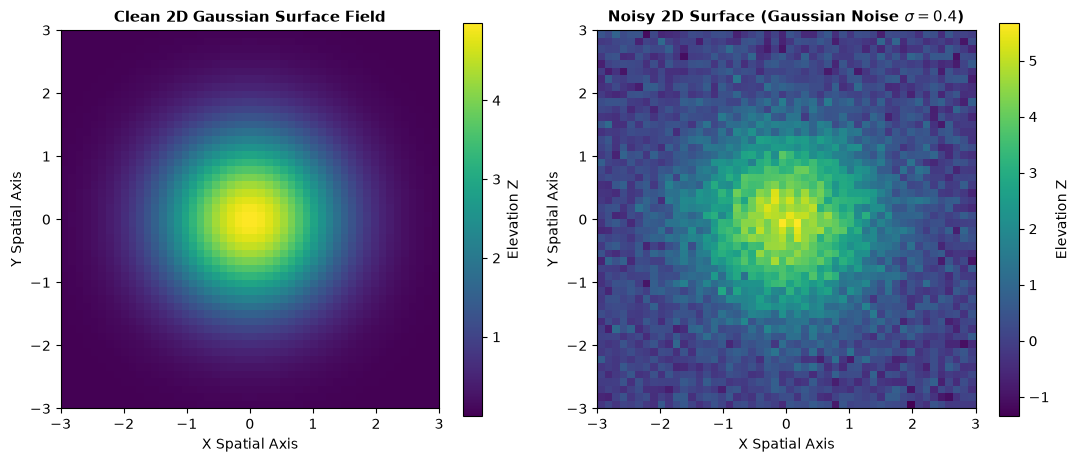

In [14]:
# --- 1. DATA GENERATION & PRINT OUTPUT ---
x_axis = np.linspace(
    start=-3.0,  # X-axis spatial start coordinate
    stop=3.0,    # X-axis spatial end coordinate
    num=50       # Grid dimension resolution
)
y_axis = np.linspace(
    start=-3.0,  # Y-axis spatial start coordinate
    stop=3.0,    # Y-axis spatial end coordinate
    num=50       # Grid dimension resolution
)
X, Y = np.meshgrid(
    x_axis,      # 1D coordinate vector along x-dimension
    y_axis       # 1D coordinate vector along y-dimension
)

# Pure 2D Gaussian Peak Surface
Z_pure = 5.0 * np.exp(-(X**2 + Y**2) / 2.0)

# Superimpose 2D Gaussian random matrix (same shape as Z_pure)
noise_2d = np.random.normal(
    loc=0.0,           # Zero mean centered noise
    scale=0.4,         # Spatial noise standard deviation
    size=Z_pure.shape  # 2D tuple matrix shape (50, 50) matching spatial meshgrid
)
Z_noisy = Z_pure + noise_2d

print("=== 5. 2D SPATIAL SURFACE + NOISE ===")
print(f"Spatial Grid Shape: {X.shape}")
print(f"Z_pure Peak Height: {Z_pure.max():.2f}")
print(f"Z_noisy Max Elevation: {Z_noisy.max():.2f}")
print(f"Noise Matrix Mean: {noise_2d.mean():.4f} | Std Dev: {noise_2d.std():.4f}\n")

# --- 2. GRAPHICAL VISUALIZATION ---
fig, (ax1, ax2) = plt.subplots(
    nrows=1,         # Number of subplot rows
    ncols=2,         # Number of subplot columns
    figsize=(11, 4.5)# Overall canvas dimensions (width, height) in inches
)

# Subplot 1: Clean 2D Heatmap Surface
im1 = ax1.imshow(
    X=Z_pure,              # 2D array of intensity/elevation values
    extent=[-3, 3, -3, 3], # Data space bounds [xmin, xmax, ymin, ymax]
    origin='lower',        # Set array origin [0,0] to bottom-left corner of plot
    cmap='viridis'         # Perceptually uniform colormap (yellow=high, dark blue=low)
)
fig.colorbar(
    mappable=im1,          # Image source for color scale
    ax=ax1,                # Target subplot axis reference
    label='Elevation Z'    # Colorbar label text
)
ax1.set_title(label='Clean 2D Gaussian Surface Field', fontsize=11, fontweight='bold')
ax1.set_xlabel(xlabel='X Spatial Axis')
ax1.set_ylabel(ylabel='Y Spatial Axis')

# Subplot 2: Noisy 2D Heatmap Surface
im2 = ax2.imshow(
    X=Z_noisy,             # 2D array of noisy elevation matrix values
    extent=[-3, 3, -3, 3], # Spatial grid coordinates extent
    origin='lower',        # Place array origin [0,0] at bottom-left corner
    cmap='viridis'         # Colormap scheme matching clean plot
)
fig.colorbar(
    mappable=im2,          # Image source for color scale
    ax=ax2,                # Target subplot axis reference
    label='Elevation Z'    # Colorbar label text
)
ax2.set_title(label='Noisy 2D Surface (Gaussian Noise $\\sigma=0.4$)', fontsize=11, fontweight='bold')
ax2.set_xlabel(xlabel='X Spatial Axis')
ax2.set_ylabel(ylabel='Y Spatial Axis')

plt.tight_layout()         # Adjust subplot parameters for optimal fitting
plt.show()

| Synthetic Signal & Noise Model | Key Characteristics | Real-Time Use Cases |
| :--- | :--- | :--- |
| **1. Trigonometric Harmonic Signal + Additive Gaussian Noise** | • Models periodic/oscillatory patterns (sine/cosine waves) corrupted by standard bell-curve noise ($N \sim \mathcal{N}(0, \sigma^2)$).<br>• Noise is zero-mean and equally spread across all time steps.<br>• Serves as the classic benchmark for Fourier Analysis, Spectral Estimation, and Bandpass Filtering. | • **Electrocardiograms (ECG) / Audio:** Filtering background thermal noise from heartbeat or sound recordings.<br>• **Vibration Monitoring:** Detecting gear/motor imbalance frequencies in rotating machinery under sensor noise. |
| **2. Exponential Decay + Uniform Measurement Error** | • Combines rapid initial decay ($N_0 e^{-\lambda t}$) with strict, bounded error limits ($[a, b]$).<br>• Error lacks long tails; values never exceed set upper/lower quantization or tolerance bounds.<br>• Tests non-linear curve fitting (`scipy.optimize.curve_fit`) when signal drops below noise floor. | • **Radioactive / Fluorescence Decay:** Tracking nuclear particle counts or chemical reaction half-lives using digitized sensors.<br>• **RC Circuit Discharge:** Modeling voltage decay across a capacitor measured by a digital multimeter with fixed display resolution. |
| **3. Polynomial Function + Sparse Outliers (Salt & Pepper / Impulse Noise)** | • Represents non-linear deterministic trends ($y = ax^2 + bx + c$) corrupted by sudden, high-magnitude extreme spikes.<br>• Most data points remain uncorrupted, but a small percentage ($\sim 5\%$) experience massive disturbance.<br>• Highlights why Mean Squared Error (MSE) fails and necessitates Robust Regression (RANSAC, Huber Loss, Median Filters). | • **Sensor Faults & Communication Dropouts:** Removing sudden voltage spikes or lost packets in IoT telemetry streams.<br>• **Financial Time Series:** Fitting smooth price/growth trends across sudden market flash crashes or fat-finger trading anomalies. |
| **4. Multi-Component Composite Signal + Heteroscedastic Noise** | • Combines multiple dynamics (linear trend + multiple harmonic sine frequencies + baseline offset).<br>• Features **non-constant variance**: noise magnitude changes over time or increases with signal magnitude ($\sigma(t)$).<br>• Requires Weighted Least Squares (WLS) or Generalized AutoRegressive Conditional Heteroskedasticity (GARCH) models. | • **Financial & Econometric Volatility:** Modeling stock prices where daily variance/volatility spikes during high-volume periods.<br>• **Radar & LiDAR Imaging:** Target tracking where noise intensity increases proportionately with distance or signal reflection strength. |
| **5. 2D Spatial Surface Field + 2D Gaussian Noise** | • Generates a 2D scalar field $Z = f(X, Y)$ using `np.meshgrid()` perturbed by a 2D matrix of independent Gaussian noise.<br>• Expands signal modeling from 1D time series to 2D spatial grid coordinates.<br>• Essential for testing 2D smoothing filters (Gaussian blur, bilateral filter) and contour plotting (`ax.contour`, `ax.contourf`). | • **Medical Imaging (MRI/CT Scans):** Denoising anatomical 2D spatial scans while preserving structural boundaries.<br>• **Geographic Information Systems (GIS):** Smoothing elevation or temperature surface heatmaps from sparse environmental sensor networks. |